In [28]:
from dataset import Dataset
from param_class import Params_community_concept_pairs, Params_concept_flow_matrix
openalex_dataset = Dataset()
openalex_dataset.concept_flow_matrix_analysis(params = Params_community_concept_pairs(concept_level = 1, less_than = False, select_mode = 'all'),
                                concept_flow_params = Params_concept_flow_matrix(disciplines = ['Mathematics'], row_normalize=False, matrix_value_cumsum_ratio = 0.95, matrix_value_count_cumsum_ratio=0.2, 
                                                                                              matrix_filter = True, matrix_imshow = False, graph_show=False, layout = "graphviz", save_G_concept_flow = False, 
                                                                                              old_matrix_version = False)) # 'Computer science'

file: /home/OpenAlex-Analysis/Prerequisite-Learning/files/edges/level_1_concepts.csv exists and override
column norm matrix shape (16, 16)
df_thresh_values.shape[0]=0
matrix_value_cumsum_ratio = 0.95 to large
filter only by matrix_value_count_cumsum_ratio=0.2
nodes 15
edge shape (51, 3)
Graph nodes 15
Graph edges 51


(<networkx.classes.digraph.DiGraph at 0x7f41c1c85be0>,
                         start                        end weight
 0                  Statistics               Econometrics   0.23
 1                   Algorithm                 Statistics  0.305
 2                   Algorithm  Mathematical optimization  0.444
 3                   Algorithm     Mathematical economics   0.18
 4                   Algorithm               Econometrics  0.164
 5                   Algorithm        Operations research  0.276
 6               Combinatorics                 Statistics  0.084
 7               Combinatorics                  Algorithm  0.199
 8               Combinatorics  Mathematical optimization   0.11
 9               Combinatorics     Mathematical economics  0.153
 10              Combinatorics               Econometrics  0.058
 11              Combinatorics        Applied mathematics  0.187
 12       Discrete mathematics                  Algorithm  0.118
 13       Discrete mathematics     

In [ ]:
# 蓝色：相关无前提关系（-2）
# 红色：反向前提（-1）
# 灰色：无关系（0）
# 绿色：正向前提（1）
# 紫色：互为前提（2）

In [1]:
from dataset import Dataset
import numpy as np

def get_evaluation_statistics(df_data, valid_index, predict_style = 'comparison'):
    predicts = df_data[predict_style][valid_index] # predict_style = prediction
    majority_votes = df_data.majority_vote[valid_index]
    # llm 为 是，predict 为 是
    tp = np.sum((majority_votes == 1) & (predicts == 1)) + np.sum((majority_votes == -1) & (predicts == -1)) + np.sum((majority_votes == 2) & (predicts.isin([-1, 1])))
    # llm 为 不是，predict 为 是
    fp = np.sum((majority_votes.isin([-2, 0])) & (predicts != 0))
    # llm 为 不是，predict 为 不是
    tn = np.sum((majority_votes.isin([-2, 0])) & (predicts == 0))
    # llm 为 是，predict 为 不是
    fn = np.sum((majority_votes == 1) & (predicts != 1)) + np.sum((majority_votes == -1) & (predicts != -1)) + np.sum((majority_votes == 2) & (predicts==0))
    
    return tp, fp, tn, fn

openalex_dataset = Dataset()
llm_prereq_relations = openalex_dataset.get_llm_relations(debug = False)
llm_prereq_relations[['concept_a','concept_b','majority_vote','related','positive','negative','comparison','prediction']]

file: /home/OpenAlex-Analysis/Prerequisite-Learning/files/edges/level_1_concepts.csv exists and override
nodes 235
edge shape (705, 3)
Graph nodes 235
Graph edges 705


,concept_a,concept_b,majority_vote,related,positive,negative,comparison,prediction
0,Public economics,Physical geography,0,0,1,1,0,0
1,Public economics,Finance,-2,1,23,19,1,0
2,Public economics,Economic policy,1,1,12,17,-1,0
3,Public economics,Anatomy,0,0,1,4,-1,0
4,Public economics,Statistics,-1,1,16,16,0,0
...,...,...,...,...,...,...,...,...
45748,Thermodynamics,Environmental health,-2,1,30,12,1,0
45749,Thermodynamics,Physical medicine and rehabilitation,0,0,3,7,-1,0
45750,Pharmacology,Environmental health,-2,1,996,640,1,1
45751,Pharmacology,Physical medicine and rehabilitation,1,1,290,189,1,0


In [ ]:
import numpy as np
import pandas as pd
value_frequency = llm_prereq_relations.max_frequency.value_counts().sort_values()
unique_values = value_frequency.index.tolist()
unique_values.sort(reverse=True)
n_prerequisites = llm_prereq_relations.majority_vote.isin([-1, 1, 2]).sum()
n_non_prerequisites = (llm_prereq_relations.majority_vote.isin([-2, 0])).sum()

tps = []
fps = []
fns = []
value_records = []
for threshold in unique_values:
    valid_index = llm_prereq_relations.max_frequency >= threshold
    tp, fp, tn, fn = get_evaluation_statistics(llm_prereq_relations, valid_index)
    value_records.append([threshold, tp, fp, tn, fn, tp+fp+tn+fn, valid_index.sum()])
    tps.append(tp)
    fps.append(fp)
    fns.append(fn)
tprs = np.array(tps) / tps[-1]
fprs = np.array(fps) / fps[-1]
df_records = pd.DataFrame(value_records, columns=['threshold', 'tp', 'fp', 'tn', 'fn', 'sum', 'total'])
df_records

,threshold,tp,fp,tn,fn,sum,total
0,708487,1,0,0,0,1,1
1,283649,1,0,0,1,2,2
2,264576,2,0,0,1,3,3
3,245901,2,1,0,1,4,4
4,235543,2,2,0,1,5,5
...,...,...,...,...,...,...,...
2861,4,1594,26632,1134,820,30180,30180
2862,3,1620,28559,1436,850,32465,32465
2863,2,1657,30993,1950,892,35492,35492
2864,1,1696,34154,2966,950,39766,39766


file: /home/OpenAlex-Analysis/Prerequisite-Learning/files/figures/sample_variational_ROC_curve_comparison_vs_llm.pdf exists and override


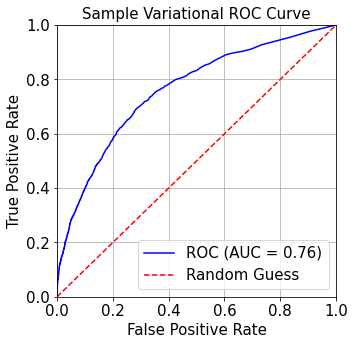

In [ ]:
openalex_dataset.visualization.plot_prerequisite_roc(tprs, fprs, save_pdf = True)

file: /home/OpenAlex-Analysis/Prerequisite-Learning/files/edges/level_1_concepts.csv exists and override
column norm matrix shape (12, 29)
df_thresh_values.shape[0]=21
column norm matrix shape (29, 12)
df_thresh_values.shape[0]=48
nodes 28
edge shape (57, 3)
Graph nodes 28
Graph edges 57
Function get_network_layout_position took 0.028s to run.


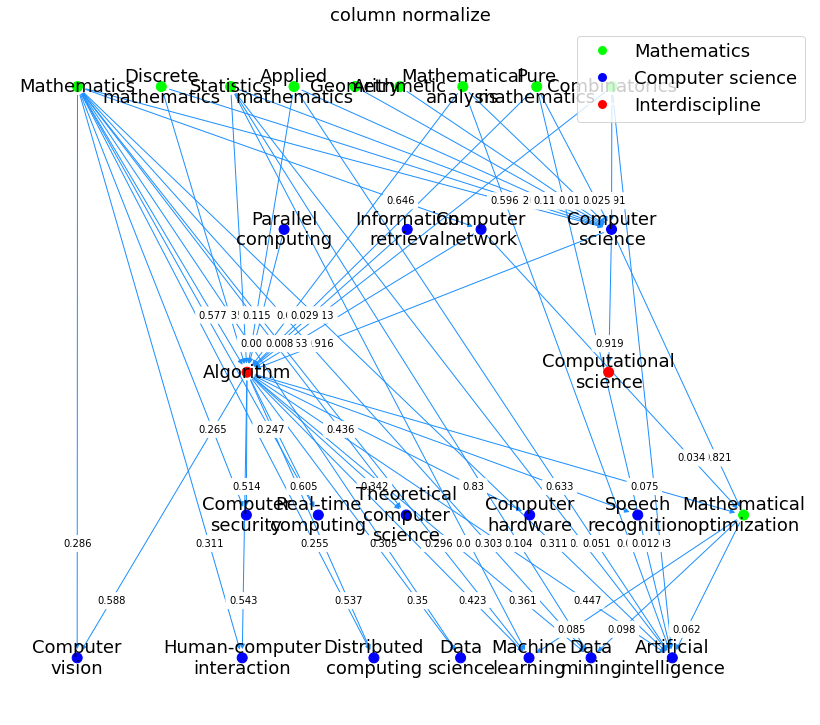

file: /home/OpenAlex-Analysis/Prerequisite-Learning/files/llm_prerequisite_relations_update_comparison.csv exists and no override (did not save)
file: /home/OpenAlex-Analysis/Prerequisite-Learning/files/edges/level_1_concepts.csv exists and override
nodes 25
edge shape (41, 3)
Graph nodes 25
Graph edges 41
Function get_network_layout_position took 0.024s to run.


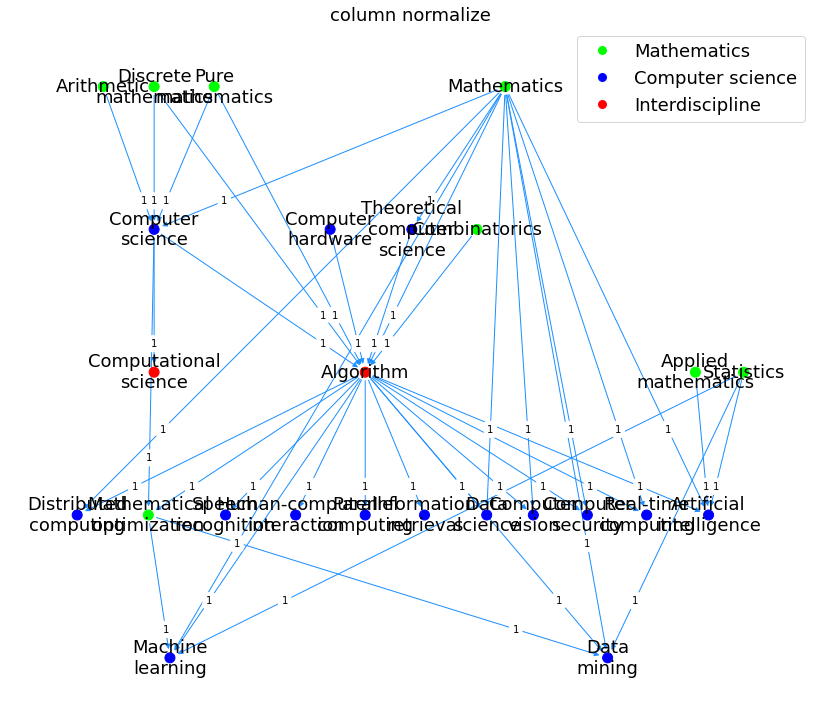

In [ ]:
from dataset import Dataset
from param_class import Params_community_concept_pairs, Params_concept_flow_matrix
openalex_dataset = Dataset()
discipline_llm_prereq_relations = openalex_dataset.get_llm_relations(debug = True, params = Params_community_concept_pairs(concept_level = 1, less_than = True, select_mode = 'collective'),
                        concept_flow_params = Params_concept_flow_matrix(disciplines = ['Mathematics', 'Computer science'], row_normalize=False, matrix_value_cumsum_ratio = 0.95, matrix_value_count_cumsum_ratio=0.2, 
                                                                                                matrix_filter = True, matrix_imshow = False, graph_show=True, layout = "graphviz", save_G_concept_flow = False, 
                                                                                                old_matrix_version = False))


In [3]:
math_discipline_llm_prereq_relations = discipline_llm_prereq_relations.loc[discipline_llm_prereq_relations.prediction.isin([-1, 1])]
math_discipline_llm_prereq_relations

,concept_a,concept_b,majority_vote,positive,negative,related,prediction,max_frequency,comparison
1517,Statistics,Algorithm,0,437,385,0,1,437,1
1530,Statistics,Machine learning,1,309,150,1,1,309,1
1537,Statistics,Data mining,1,313,174,1,1,313,1
1588,Statistics,Artificial intelligence,1,1128,832,1,1,1128,1
1698,Statistics,Computer science,-2,7222,6879,1,1,7222,1
2695,Human-computer interaction,Algorithm,-1,358,527,1,-1,527,-1
2867,Human-computer interaction,Mathematics,-2,251,302,1,-1,302,-1
6693,Algorithm,Combinatorics,-1,1144,1287,1,-1,1287,-1
6702,Algorithm,Discrete mathematics,-1,362,395,1,-1,395,-1
6705,Algorithm,Machine learning,1,2050,786,1,1,2050,1


In [5]:
math_discipline_llm_prereq_relations[30:60]

,concept_a,concept_b,majority_vote,positive,negative,related,prediction,max_frequency,comparison
7151,Combinatorics,Computer science,-2,9200,8622,1,1,9200,1
9608,Discrete mathematics,Computer science,1,2629,2498,1,1,2629,1
10251,Machine learning,Mathematical optimization,-1,227,412,1,-1,412,-1
10400,Machine learning,Mathematics,-1,549,1434,1,-1,1434,-1
10665,Distributed computing,Mathematics,-1,624,734,1,-1,734,-1
12085,Data mining,Mathematical optimization,-1,213,297,1,-1,297,-1
12234,Data mining,Mathematics,-1,543,917,1,-1,917,-1
12904,Mathematical optimization,Artificial intelligence,-2,1896,1693,1,1,1896,1
13000,Mathematical optimization,Computer network,0,456,801,0,-1,801,-1
13014,Mathematical optimization,Computer science,-1,12875,19289,1,-1,19289,-1


In [5]:
from dataset import Dataset
from param_class import Params_community_concept_pairs, Params_concept_flow_matrix
openalex_dataset = Dataset()
llm_prereq_relations_0 = openalex_dataset.get_llm_relations(debug = False, params = Params_community_concept_pairs(concept_level = 1, less_than = True, select_mode = 'collective'),
                        concept_flow_params = Params_concept_flow_matrix(disciplines = [], row_normalize=False, matrix_value_cumsum_ratio = 0.94, matrix_value_count_cumsum_ratio=0.1, 
                                                                                                matrix_filter = True, matrix_imshow = False, graph_show=False, layout = "graphviz", save_G_concept_flow = False, 
                                                                                                old_matrix_version = False))
llm_prereq_relations_1 = openalex_dataset.get_llm_relations(debug = False, params = Params_community_concept_pairs(concept_level = 1, less_than = True, select_mode = 'collective'),
                        concept_flow_params = Params_concept_flow_matrix(disciplines = [], row_normalize=False, matrix_value_cumsum_ratio = 0.95, matrix_value_count_cumsum_ratio=0.2, 
                                                                                                matrix_filter = True, matrix_imshow = False, graph_show=False, layout = "graphviz", save_G_concept_flow = False, 
                                                                                                old_matrix_version = False))
llm_prereq_relations_2 = openalex_dataset.get_llm_relations(debug = False, params = Params_community_concept_pairs(concept_level = 1, less_than = True, select_mode = 'collective'),
                        concept_flow_params = Params_concept_flow_matrix(disciplines = [], row_normalize=False, matrix_value_cumsum_ratio = 0.96, matrix_value_count_cumsum_ratio=0.3, 
                                                                                                matrix_filter = True, matrix_imshow = False, graph_show=False, layout = "graphviz", save_G_concept_flow = False, 
                                                                                                old_matrix_version = False))
llm_prereq_relations_3 = openalex_dataset.get_llm_relations(debug = False, params = Params_community_concept_pairs(concept_level = 1, less_than = True, select_mode = 'collective'),
                        concept_flow_params = Params_concept_flow_matrix(disciplines = [], row_normalize=False, matrix_value_cumsum_ratio = 0.97, matrix_value_count_cumsum_ratio=0.4, 
                                                                                                matrix_filter = True, matrix_imshow = False, graph_show=False, layout = "graphviz", save_G_concept_flow = False, 
                                                                                                old_matrix_version = False))
llm_prereq_relations_4 = openalex_dataset.get_llm_relations(debug = False, params = Params_community_concept_pairs(concept_level = 1, less_than = True, select_mode = 'collective'),
                        concept_flow_params = Params_concept_flow_matrix(disciplines = [], row_normalize=False, matrix_value_cumsum_ratio = 0.98, matrix_value_count_cumsum_ratio=0.5, 
                                                                                                matrix_filter = True, matrix_imshow = False, graph_show=False, layout = "graphviz", save_G_concept_flow = False, 
                                                                                                old_matrix_version = False))

file: /home/OpenAlex-Analysis/Prerequisite-Learning/files/edges/level_1_concepts.csv exists and override
nodes 204
edge shape (512, 3)
Graph nodes 204
Graph edges 512
file: /home/OpenAlex-Analysis/Prerequisite-Learning/files/edges/level_1_concepts.csv exists and override
nodes 211
edge shape (546, 3)
Graph nodes 211
Graph edges 546
file: /home/OpenAlex-Analysis/Prerequisite-Learning/files/edges/level_1_concepts.csv exists and override
nodes 215
edge shape (578, 3)
Graph nodes 215
Graph edges 578
file: /home/OpenAlex-Analysis/Prerequisite-Learning/files/edges/level_1_concepts.csv exists and override
nodes 226
edge shape (640, 3)
Graph nodes 226
Graph edges 640
file: /home/OpenAlex-Analysis/Prerequisite-Learning/files/edges/level_1_concepts.csv exists and override
nodes 235
edge shape (705, 3)
Graph nodes 235
Graph edges 705


file: /home/OpenAlex-Analysis/Prerequisite-Learning/files/figures/contingency_tables.pdf exists and override


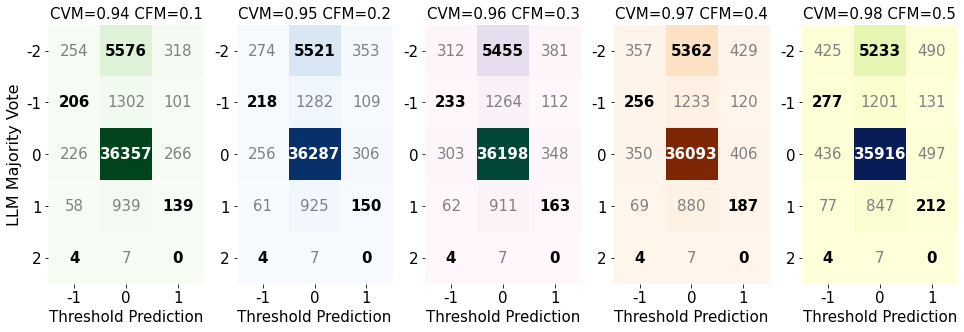

In [4]:
df_list = [llm_prereq_relations_0, llm_prereq_relations_1, llm_prereq_relations_2, llm_prereq_relations_3, llm_prereq_relations_4]
highlight_value_pairs = [(-1, -1), (-1, 2), (0, -2), (0, 0), (1, 1), (1, 2)]
titles = [f'CVM={0.94} CFM={0.1}', f'CVM={0.95} CFM={0.2}', f'CVM={0.96} CFM={0.3}', f'CVM={0.97} CFM={0.4}', f'CVM={0.98} CFM={0.5}']
openalex_dataset.visualization.plot_multiple_contingency_heatmaps_plt(df_list, highlight_value_pairs, 15, base_width = 0.9, titles=titles, n_cols=5, grid_visible=False, save_pdf=True)

Relation value: 0	 Samples: 42997	 Positives: 17653
Relation value: 1	 Samples: 2756	 Positives: 1696


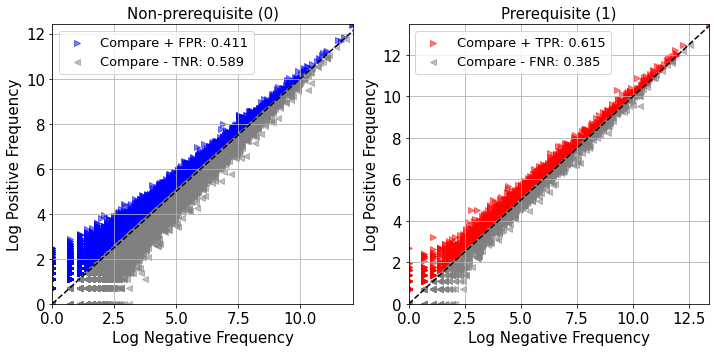

In [10]:
openalex_dataset.visualization.plot_concept_relations(llm_prereq_relations_4, value_column = 'majority_vote', combine_pos_neg=True, combine_neg2_zero = True)
